### Using randomly generated  (age of patient) to predict the next dependant variable (prior disability)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random as rn
import seaborn as sns 

In [35]:
num_samples=1000

In [36]:
df_a=pd.read_csv("combo_age_disability.csv", index_col="prior_disability")

In [37]:
df_a

,37.5,42.5,47.5,52.5,57.5,62.5,67.5,72.5,77.5,82.5,87.5,92.5
prior_disability,,,,,,,,,,,,
0,0.01649,0.01335,0.01987,0.03311,0.04535,0.05496,0.05876,0.07169,0.08016,0.06254,0.03868,0.01494
1,0.00161,0.00138,0.00254,0.00489,0.00805,0.01231,0.01653,0.02494,0.03485,0.03610,0.02808,0.01451
2,0.00059,0.00044,0.00102,0.00189,0.00344,0.00507,0.00723,0.01081,0.01673,0.02239,0.02181,0.01546
3,0.00048,0.00034,0.00059,0.00137,0.00225,0.00366,0.00539,0.00926,0.01560,0.02405,0.02936,0.02952
4,0.00019,0.00021,0.00022,0.00050,0.00108,0.00153,0.00238,0.00412,0.00721,0.01055,0.01496,0.01855
5,0.00003,0.00002,0.00007,0.00013,0.00022,0.00036,0.00054,0.00108,0.00181,0.00247,0.00318,0.00415


In [38]:
vals_f1 = df_a.columns
probs_f1 = df_a.sum(axis='rows')  # for each column, sum all its values
f1 = np.random.choice(vals_f1, size=num_samples, p=probs_f1)

In [39]:
# Create an empty array for feature 2:
f2 = np.full(len(f1), 42)  # 42 is our definitely-wrong value
vals_f2 = df_a.index

# For each option for feature 1, pick out the probabilities for feature 2:
for v in vals_f1:
    # Which indices of f1 have this value?
    inds_v = np.where(f1 == v)
    # How many of our generated f1 have this value?
    num_v = len(inds_v[0])
    # Probabilities for this value of f1:
    probs_v = df_a[v]
    # Normalise (make them sum to 1):
    probs_v = probs_v / probs_v.sum()
    # Generate new values for feature 2 for this value of feature 1:
    f2_v = np.random.choice(vals_f2, size=num_v, p=probs_v)
    # Place these into the main f2 array:
    f2[inds_v] = f2_v

    # Print this to show what's happening:
    print(v, num_v, probs_v, f2_v)

37.5 21 prior_disability
0    0.850438
1    0.083032
2    0.030428
3    0.024755
4    0.009799
5    0.001547
Name: 37.5, dtype: float64 [0 0 0 0 0 0 3 0 0 0 0 1 0 0 2 0 1 0 0 0 0]
42.5 17 prior_disability
0    0.848158
1    0.087675
2    0.027954
3    0.021601
4    0.013342
5    0.001271
Name: 42.5, dtype: float64 [0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 1 0]
47.5 19 prior_disability
0    0.817359
1    0.104484
2    0.041958
3    0.024270
4    0.009050
5    0.002879
Name: 47.5, dtype: float64 [0 0 0 0 0 2 0 0 0 0 0 1 0 0 0 0 0 0 0]
52.5 49 prior_disability
0    0.790403
1    0.116734
2    0.045118
3    0.032705
4    0.011936
5    0.003103
Name: 52.5, dtype: float64 [0 1 0 0 0 3 0 0 0 0 0 0 0 0 0 3 0 0 2 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 3 0 0
 0 0 0 0 0 1 0 0 0 1 1 0]
57.5 59 prior_disability
0    0.750952
1    0.133300
2    0.056963
3    0.037258
4    0.017884
5    0.003643
Name: 57.5, dtype: float64 [0 2 0 0 0 3 0 0 3 0 0 0 0 0 0 0 2 1 1 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 1 0 0
 0 0 0 3 2 0 4 0 2 0 0 0

In [40]:
pd.DataFrame([f1, f2]).T

,0,1
0,92.5,3
1,72.5,1
2,82.5,2
3,67.5,1
4,92.5,2
...,...,...
995,82.5,3
996,77.5,4
997,77.5,4
998,92.5,3


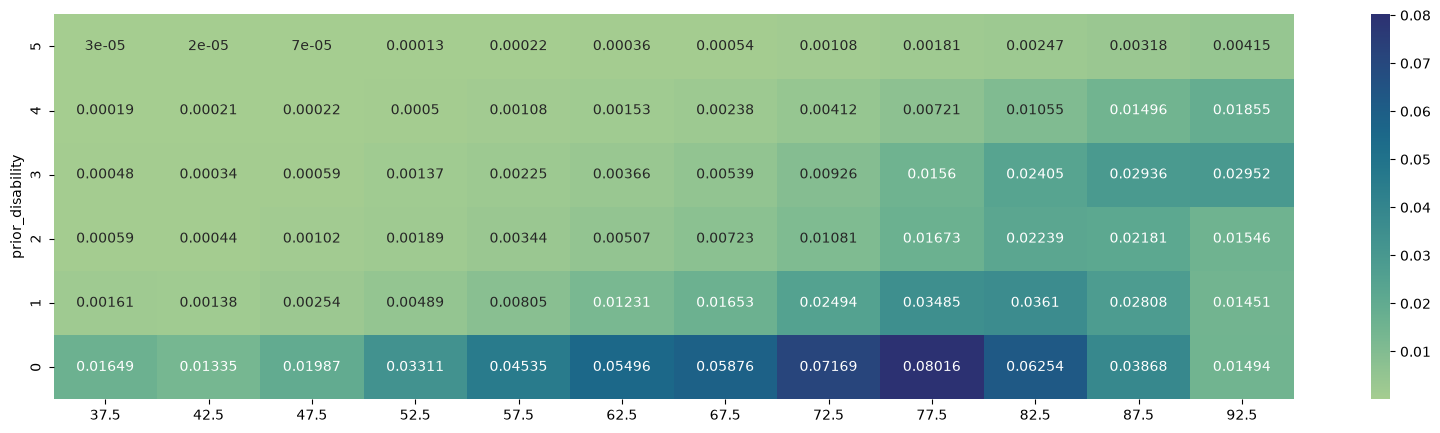

In [45]:
plt.figure(figsize=(20,5))
ax=sns.heatmap(df_a, cmap="crest", annot=True,fmt="g")#format- general (not scientific)
ax.invert_yaxis()
plt.show()